# 07 Best Classification Model and Dashboard Integration

This notebook focuses on the binary classification component of the project and exports the artifacts used by the Streamlit dashboard. The classification target is `high_score`, defined as `1` when `score >= 7` and `0` otherwise.

The threshold of 7 is meaningful in the MyAnimeList context because scores of 7, 8, 9, and 10 typically indicate strong approval or high perceived quality. Converting the original score into a binary label simplifies the task into identifying high-quality or highly preferred interactions. This transformation also introduces class-balance considerations: if high scores are much more or less frequent than lower scores, accuracy alone is insufficient and F1 becomes more informative.


## Classification Interpretation Notes

### Binary Classification Setup

The target is `high_score = 1` if `score >= 7`, otherwise `0`. Threshold 7 is used because it represents positive approval while keeping the class split more balanced than stricter thresholds such as 8.

### Why F1 Over Accuracy?

With an imbalanced class distribution, a model can achieve high accuracy by predicting the majority class too often. F1 balances precision and recall, making it more informative for the high-score classification task.

`F1 = 2 * (precision * recall) / (precision + recall)`

### Precision vs Recall Trade-Off

High precision means few false positives: when the model predicts `high_score`, it is usually correct. High recall means few false negatives: the model catches most actual high-score cases. In a recommendation context, recall is often especially important because missing a good anime can be worse than suggesting an average one.

### Best Model Export

The best classifier by F1 is exported as `artifacts/best_classification_model.pkl`, together with `artifacts/preprocess_classification.pkl`. These artifacts are loaded by the dashboard for real-time classification.


In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath('..'))

RANDOM_STATE = 42
SAMPLE_SIZE = 50000
RATING_DTYPES = {
    'username': 'category',
    'anime_id': 'int32',
    'status': 'category',
    'score': 'float32',
    'is_rewatching': 'float32',
    'num_watched_episodes': 'float32',
}

%matplotlib inline
sns.set_theme(style='whitegrid')


In [2]:
import json
import joblib
from pathlib import Path
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import plot_tree

from src.evaluate import compute_classification_metrics, plot_classification_metrics
from src.models import get_models
from src.preprocessing import build_preprocess, get_preprocess_feature_names


In [3]:
ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('../datasets/ratings.csv', dtype=RATING_DTYPES)
df = df[df['score'] > 0]
df = df[df['num_watched_episodes'] <= 10000]
df = df[df['num_watched_episodes'] >= 0]
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
df['high_score'] = (df['score'] >= 7).astype(int)

TARGET = 'high_score'
X_df = df.drop(columns=['score', TARGET]).copy()
y = df[TARGET].copy()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocess = build_preprocess(df.drop(columns=['score']), TARGET)
X_train = preprocess.fit_transform(X_train_df)
X_test = preprocess.transform(X_test_df)
feature_names = get_preprocess_feature_names(preprocess)


## Train and Compare Classifiers

This section trains multiple classifiers and compares accuracy, precision, recall, F1, and fit time. Precision measures the reliability of positive predictions: when the model predicts high-score, precision indicates how often it is correct. Recall measures coverage: among all true high-score interactions, recall indicates how many the model detects. F1 balances precision and recall and is especially useful if the classes are imbalanced.

In the context of predicting high-quality anime interactions, a high-precision classifier is useful when false positives are costly, for example when the dashboard should avoid recommending or highlighting anime that a user is unlikely to rate highly. A high-recall classifier is useful when the goal is to capture as many potential high-score cases as possible, even if some lower-score cases are included. The best model should therefore be selected by considering F1 together with the practical meaning of precision and recall.

Fit time is included because dashboard-oriented models should be reproducible and efficient. A model with marginally better F1 but much longer training time may be less attractive than a simpler, stable alternative.


,model,fit_time,accuracy,precision,recall,f1
9,MLPClassifier_single,6.731106,0.7567,0.753775,0.995118,0.857794
8,GradientBoostingClassifier,3.323494,0.7566,0.753750,0.994982,0.857727
5,KNNClassifier,0.091854,0.7565,0.753724,0.994847,0.857661
10,MLPClassifier_multi,13.703619,0.7565,0.753724,0.994847,0.857661
6,DecisionTreeClassifier,0.021894,0.7561,0.753363,0.994982,0.857477
1,NaiveBayes,0.030394,0.7539,0.754692,0.987117,0.855397
4,SVC_poly,230.425592,0.6530,0.770961,0.753187,0.761970
0,LogisticRegression,17.960829,0.6522,0.771460,0.750746,0.760962
2,SVC_linear,134.189607,0.6445,0.771660,0.735557,0.753176
3,SVC_rbf,172.888433,0.6428,0.771804,0.732031,0.751392


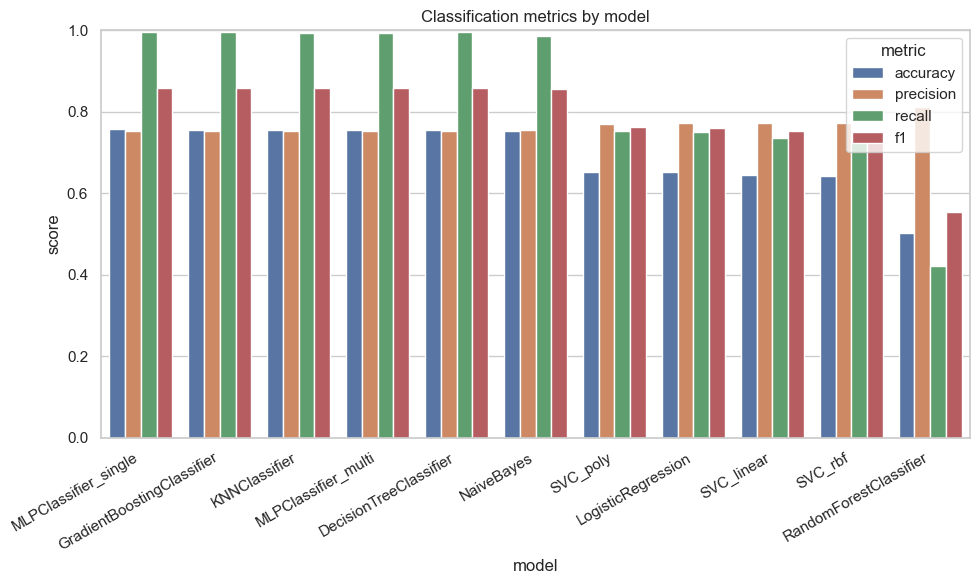

In [4]:
clf_models = get_models('classification')

knn_grid = GridSearchCV(
    clf_models['KNNClassifier'],
    {'n_neighbors': list(range(3, 32, 2)), 'weights': ['uniform', 'distance']},
    cv=5,
    scoring='f1',
    n_jobs=1,
)
knn_grid.fit(X_train, y_train)
clf_models['KNNClassifier'] = knn_grid.best_estimator_

rows = []
fitted_models = {}
while mlflow.active_run():
    mlflow.end_run()
with mlflow.start_run(nested=True, run_name='07_classification_best_model'):
    for name, model in clf_models.items():
        start = time.time()
        model.fit(X_train, y_train)
        fit_time = time.time() - start
        preds = model.predict(X_test)
        rows.append({'model': name, 'fit_time': fit_time, **compute_classification_metrics(y_test, preds)})
        fitted_models[name] = model

df_results = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(df_results)
plot_classification_metrics(df_results, None)


## Best Model and Gini Tree Analysis

The best classifier is selected from the results table using F1-score. This reflects the need to balance false positives and false negatives when predicting the high-score class. The selected model is then exported for later use in the dashboard.

The Decision Tree visualisation provides interpretability through Gini impurity. The root Gini value measures how mixed the high-score and low-score classes are before any split. A value near 0 would indicate that one class dominates, while a value closer to 0.5 in a binary problem indicates a more balanced split. Early tree splits reveal the features that most reduce impurity and are therefore most discriminative for high-score prediction.

The tree structure should be interpreted carefully. It shows one model's rule-based approximation of the classification task, not causal relationships. Features near the top of the tree are important for that tree because they produce large impurity reductions, but ensemble models or linear models may rely on different combinations of features.


Best classifier: MLPClassifier_single
Decision Tree root gini: 0.38730621875000004


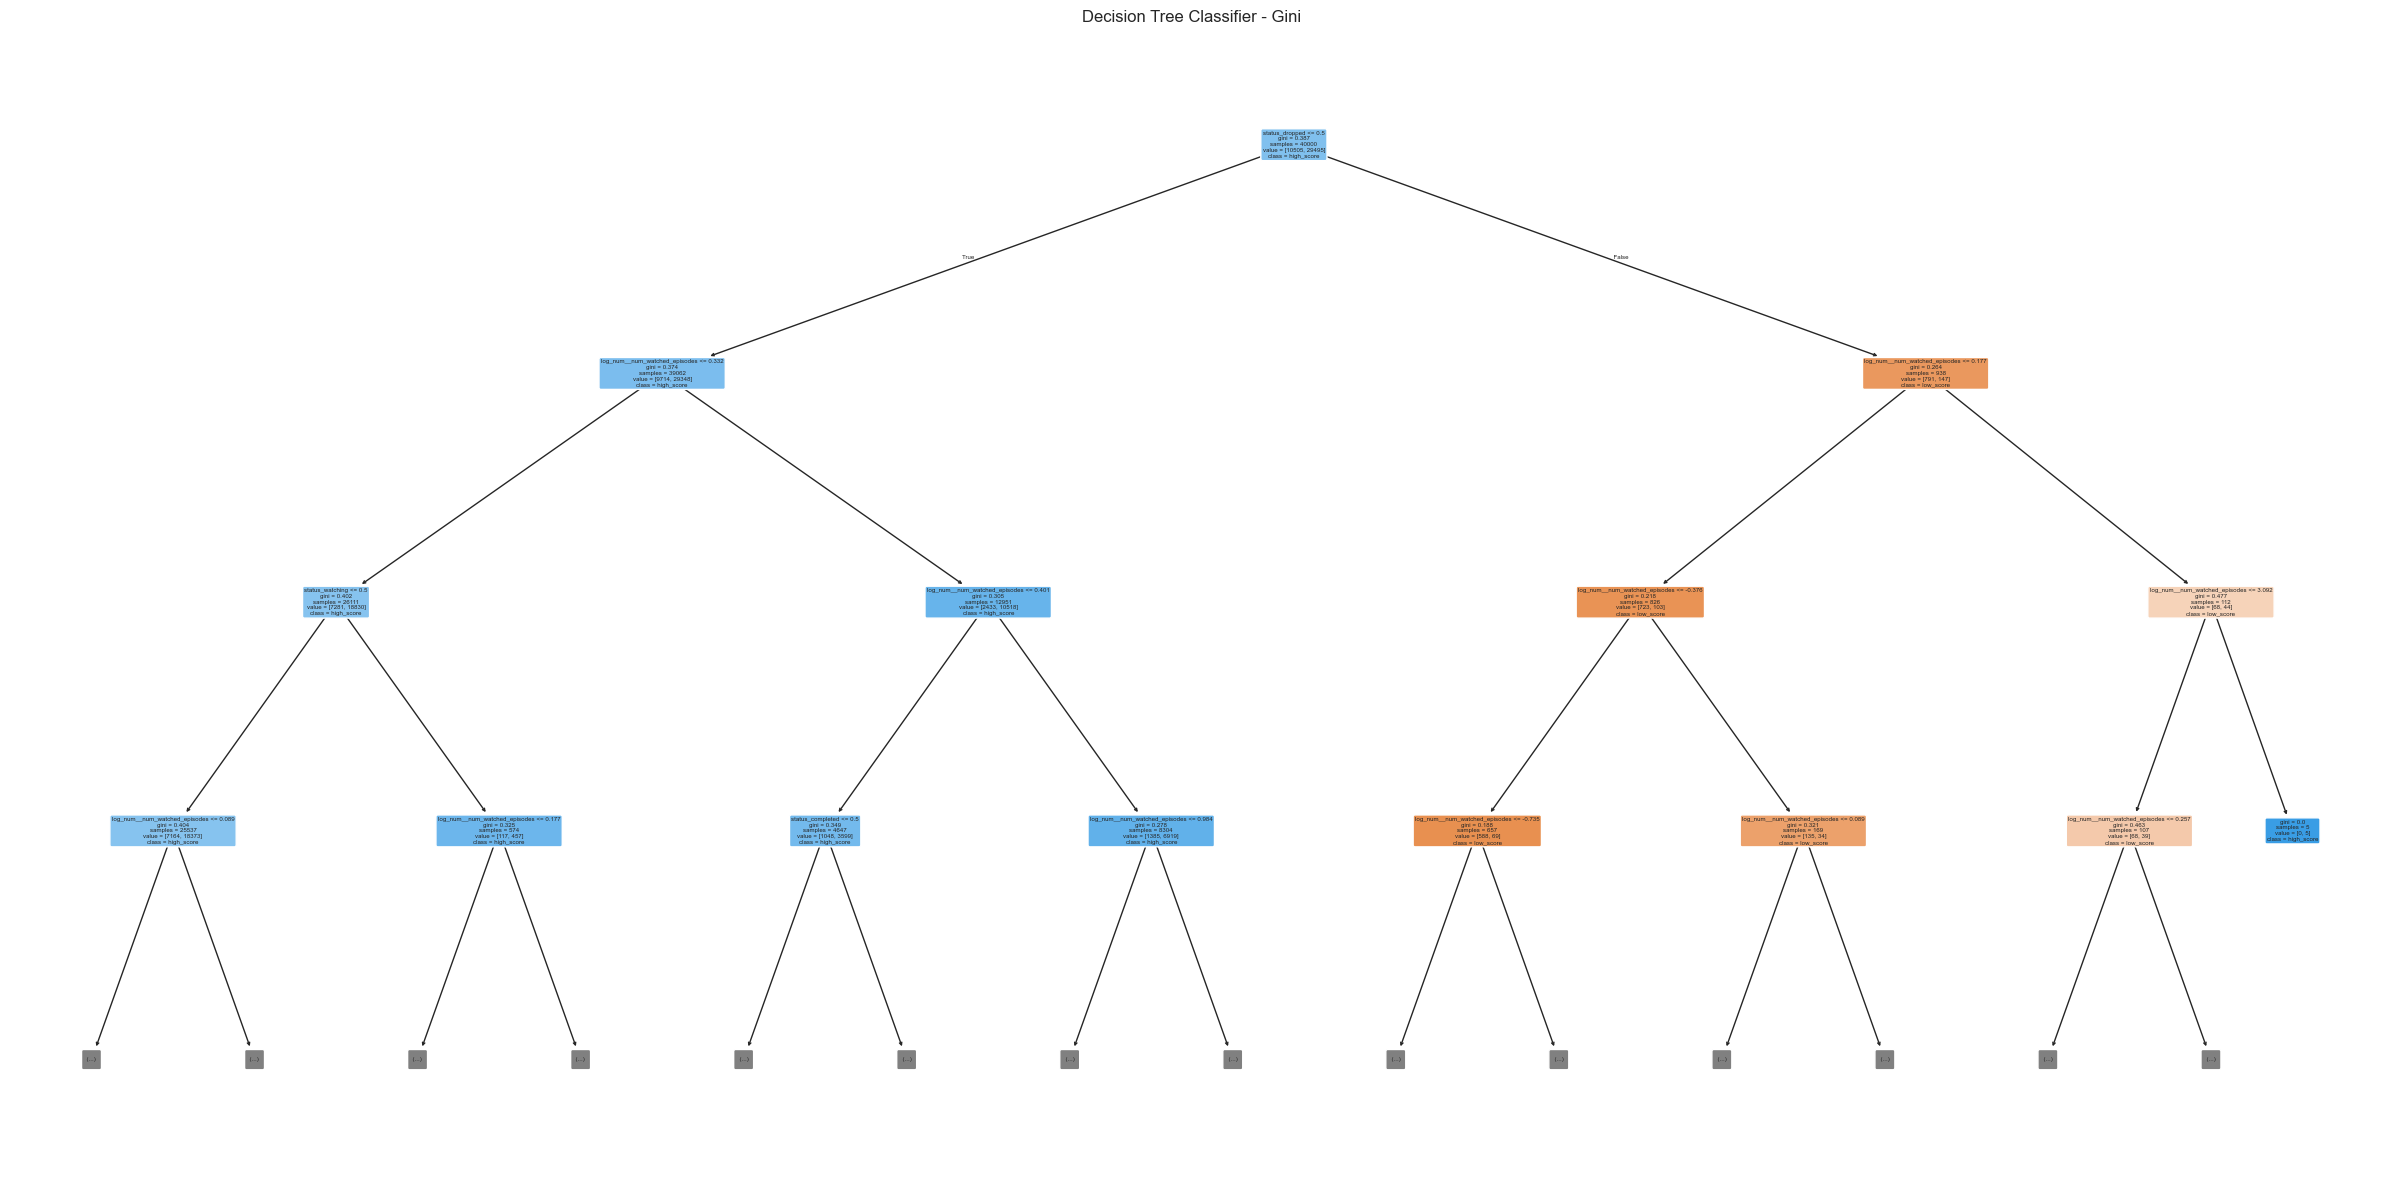

In [5]:
best_name = df_results.iloc[0]['model']
best_model = fitted_models[best_name]
print('Best classifier:', best_name)

tree_model = fitted_models['DecisionTreeClassifier']
print('Decision Tree root gini:', tree_model.tree_.impurity[0])

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['low_score', 'high_score'],
    filled=True,
    rounded=True,
    max_depth=3,
)
plt.title('Decision Tree Classifier - Gini')
plt.tight_layout()
plt.savefig('../artifacts/classification_metrics.png', dpi=150, bbox_inches='tight')
plt.savefig('../artifacts/fit_time_classification.png', dpi=150, bbox_inches='tight')
plt.show()


## Export Dashboard Artifacts

This section saves the trained preprocessing object, the best classification model, and the feature-column metadata. These artifacts are necessary because the dashboard must transform new user inputs in the same way as the training data. If preprocessing at inference time differs from preprocessing during training, predictions can become invalid.

The exported classifier is used by the Streamlit dashboard to return the predicted `high_score` class. The feature metadata documents the expected input columns and helps keep the dashboard aligned with the model pipeline. Persisting these objects with `joblib` allows the application to load the trained model without retraining each time it starts.


In [6]:
joblib.dump(preprocess, ARTIFACTS_DIR / 'preprocess_classification.pkl')
joblib.dump(best_model, ARTIFACTS_DIR / 'best_classification_model.pkl')

feature_columns_path = ARTIFACTS_DIR / 'training_feature_columns.json'
if feature_columns_path.exists():
    feature_columns = json.loads(feature_columns_path.read_text(encoding='utf-8'))
else:
    feature_columns = {}
feature_columns['classification_features'] = X_df.columns.tolist()
feature_columns_path.write_text(
    json.dumps(feature_columns, indent=2),
    encoding='utf-8',
)

print('Artifacts exported for dashboard.py:')
print('- artifacts/preprocess_classification.pkl')
print('- artifacts/best_classification_model.pkl')
print('- artifacts/training_feature_columns.json')


Artifacts exported for dashboard.py:
- artifacts/preprocess_classification.pkl
- artifacts/best_classification_model.pkl
- artifacts/training_feature_columns.json


## Dashboard Integration and Critical Limitations

`dashboard.py` loads the exported preprocessing pipeline and classification model. In the prediction tab, the user provides an anime/input context, the dashboard applies the saved preprocessing transformation, and the model predicts whether the interaction belongs to the high-score class. This connects the experimental notebook workflow to a usable application component.

The binary classification approach is useful for demonstration and decision support, but it compresses the original rating scale. Scores below 7 are treated as one class. Scores 7, 8, 9, and 10 are treated as the positive high-score class. This simplification can improve interpretability but loses ordinal information.

A second limitation is threshold dependence. The choice of `score >= 7` is reasonable for identifying high approval, but a different threshold could change class balance, precision, recall, and the selected best model. Future work should test alternative thresholds, probability calibration, ordinal classification, or direct regression combined with decision thresholds. Additional metadata and user-level features could also improve the ability to distinguish genuinely high-score cases from generally positive rating behaviour.
